In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
class StochasticBiddingEnvironment:
    def __init__(self, market_prices, probabilities, seed=None):

        self.market_prices = np.array(market_prices)
        self.probabilities = np.array(probabilities)

        assert np.isclose(self.probabilities.sum(), 1.0), "Probabilities must sum to 1."

        self.rng = np.random.default_rng(seed)

    def round(self):
        return self.rng.choice(self.market_prices, p=self.probabilities)

In [ ]:
class UCB1BiddingAgent:
    def __init__(self, bids_set, valuation):

        self.bids_set = np.array(bids_set)
        self.valuation = valuation

        self.K = len(self.bids_set)

        self.n_pulls = np.zeros(self.K)
        self.reward_sum = np.zeros(self.K)

        self.t = 0

    def pull_arm(self):

        for arm in range(self.K):
            if self.n_pulls[arm] == 0:
                return arm

        avg_rewards = self.reward_sum / self.n_pulls

        confidence = np.sqrt(
            2 * np.log(self.t) / self.n_pulls
        )

        ucb_values = avg_rewards + confidence

        return int(np.argmax(ucb_values))

    def update(self, pulled_arm, reward):

        self.t += 1
        self.n_pulls[pulled_arm] += 1
        self.reward_sum[pulled_arm] += reward

In [ ]:
def compute_reward(bid, market_price, valuation):
    win = bid >= market_price

    if win:
        reward = valuation - bid
    else:
        reward = 0.0

    return reward, win

In [ ]:
def compute_clairvoyant_bid(bids_set, valuation, market_prices, probabilities):
    expected_rewards = []

    for bid in bids_set:
        win_prob = np.sum(probabilities[market_prices <= bid])
        expected_reward = (valuation - bid) * win_prob
        expected_rewards.append(expected_reward)

    expected_rewards = np.array(expected_rewards)

    best_arm = int(np.argmax(expected_rewards))
    best_bid = bids_set[best_arm]
    best_expected_reward = expected_rewards[best_arm]

    return best_arm, best_bid, best_expected_reward, expected_rewards

In [ ]:
def run_ucb1_experiment(T, bids_set, valuation, market_prices, probabilities, seed=None):
    env = StochasticBiddingEnvironment(
        market_prices=market_prices,
        probabilities=probabilities,
        seed=seed
    )

    agent = UCB1BiddingAgent(
        bids_set=bids_set,
        valuation=valuation
    )

    best_arm, best_bid, best_expected_reward, expected_rewards = compute_clairvoyant_bid(
        bids_set=bids_set,
        valuation=valuation,
        market_prices=market_prices,
        probabilities=probabilities
    )

    chosen_bids = []
    rewards = []
    wins = []
    regrets = []

    for t in range(T):
        pulled_arm = agent.pull_arm()
        bid = bids_set[pulled_arm]

        market_price = env.round()

        reward, win = compute_reward(
            bid=bid,
            market_price=market_price,
            valuation=valuation
        )

        agent.update(pulled_arm, reward)

        regret = best_expected_reward - reward

        chosen_bids.append(bid)
        rewards.append(reward)
        wins.append(win)
        regrets.append(regret)

    results = {
        "chosen_bids": np.array(chosen_bids),
        "rewards": np.array(rewards),
        "wins": np.array(wins),
        "regrets": np.array(regrets),
        "cum_rewards": np.cumsum(rewards),
        "cum_regret": np.cumsum(regrets),
        "best_bid": best_bid,
        "best_expected_reward": best_expected_reward,
        "expected_rewards": expected_rewards,
        "n_pulls": agent.n_pulls
    }

    return results

In [ ]:
T = 5000

valuation = 1.0

bids_set = np.linspace(0.0, valuation, 11)

market_prices = np.array([0.1, 0.3, 0.5, 0.7, 0.9])
probabilities = np.array([0.15, 0.25, 0.30, 0.20, 0.10])

results = run_ucb1_experiment(
    T=T,
    bids_set=bids_set,
    valuation=valuation,
    market_prices=market_prices,
    probabilities=probabilities,
    seed=42
)

print("Best clairvoyant bid:", results["best_bid"])
print("Best expected reward:", results["best_expected_reward"])
print("Total reward:", results["cum_rewards"][-1])
print("Final cumulative regret:", results["cum_regret"][-1])
print("Number of pulls per bid:")
for bid, pulls in zip(bids_set, results["n_pulls"]):
    print(f"bid={bid:.2f} -> {int(pulls)} pulls")

Best clairvoyant bid: 0.5
Best expected reward: 0.35
Total reward: 1395.7000000000003
Final cumulative regret: 354.3000000000288
Number of pulls per bid:
bid=0.00 -> 84 pulls
bid=0.10 -> 172 pulls
bid=0.20 -> 152 pulls
bid=0.30 -> 678 pulls
bid=0.40 -> 395 pulls
bid=0.50 -> 1956 pulls
bid=0.60 -> 617 pulls
bid=0.70 -> 489 pulls
bid=0.80 -> 234 pulls
bid=0.90 -> 139 pulls
bid=1.00 -> 84 pulls


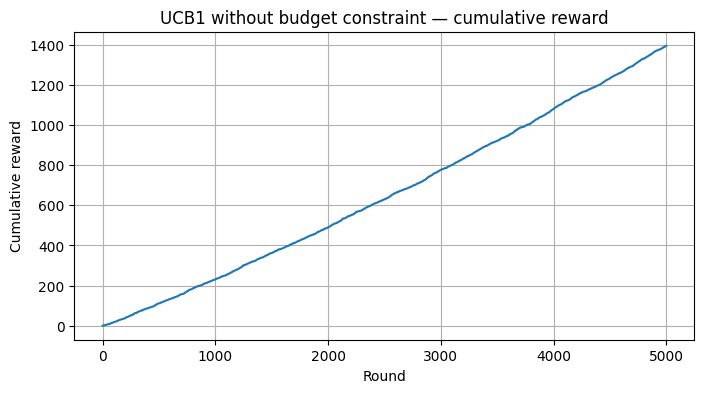

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(results["cum_rewards"])
plt.xlabel("Round")
plt.ylabel("Cumulative reward")
plt.title("UCB1 without budget constraint — cumulative reward")
plt.grid(True)
plt.show()

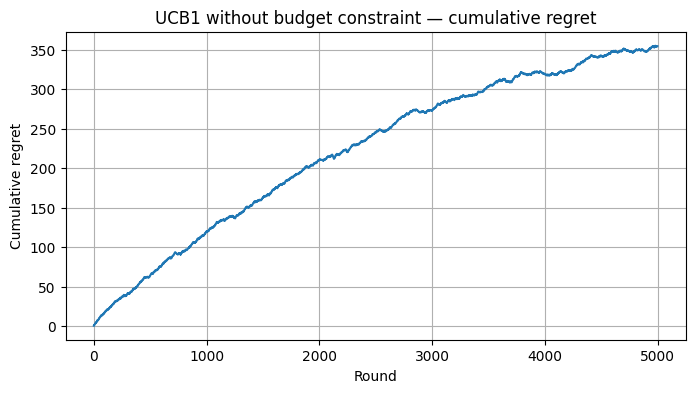

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(results["cum_regret"])
plt.xlabel("Round")
plt.ylabel("Cumulative regret")
plt.title("UCB1 without budget constraint — cumulative regret")
plt.grid(True)
plt.show()

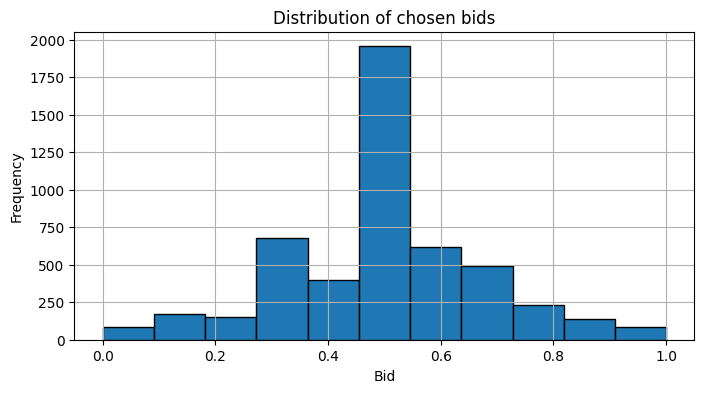

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(results["chosen_bids"], bins=len(bids_set), edgecolor="black")
plt.xlabel("Bid")
plt.ylabel("Frequency")
plt.title("Distribution of chosen bids")
plt.grid(True)
plt.show()

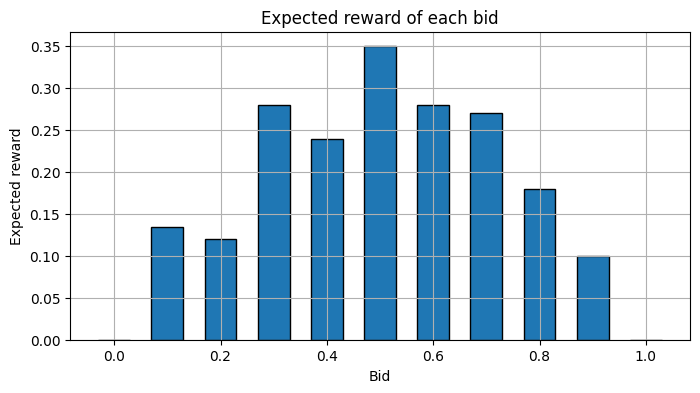

In [ ]:
plt.figure(figsize=(8, 4))
plt.bar(bids_set, results["expected_rewards"], width=0.06, edgecolor="black")
plt.xlabel("Bid")
plt.ylabel("Expected reward")
plt.title("Expected reward of each bid")
plt.grid(True)
plt.show()